### Problem A-i

Use this notebook to write your code for perceptron by filling in the sections marked `# TODO` and running all cells.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

from perceptron_helper import (
    predict,
    plot_data,
    boundary,
    plot_perceptron,
)

%matplotlib inline

##### Implementation of Perceptron

First, we will implement the perceptron algorithm. Fill in the `update_perceptron()` function so that it finds a single misclassified point and updates the weights and bias accordingly. If no point exists, the weights and bias should not change.

Hint: You can use the `predict()` helper method, which labels a point 1 or -1 depending on the weights and bias.

In [2]:
def update_perceptron(X, Y, w, b):
    print("current w = %s, current b = %.1f" % (w, b))
    next_w, next_b = np.copy(w), np.copy(b)
    if predict(X, w, b) <= 0:
        print("misclassified point (%s, %d)" % (X, Y))
        next_w += Y * X
        next_b += Y

    return next_w, next_b

def run_perceptron(X, Y, w, b, max_iter):
    for _ in range(max_iter):
       for i in range(len(X)):
            w, b = update_perceptron(X[i], Y[i], w, b)

    return w, b

### Problem A-ii

##### Visualizing a Toy Dataset

We will begin by training our perceptron on a toy dataset of 3 points. The green points are labelled +1 and the red points are labelled -1. We use the helper function `plot_data()` to do so.

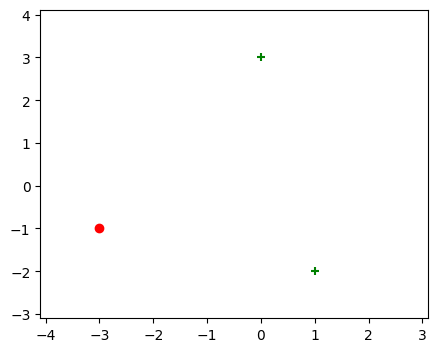

In [3]:
X = np.array([[ -3, -1], [0, 3], [1, -2]])
Y = np.array([ -1, 1, 1])

fig = plt.figure(figsize=(5,4))
ax = fig.gca(); ax.set_xlim(-4.1, 3.1); ax.set_ylim(-3.1, 4.1)
plot_data(X, Y, ax)

##### Running the Perceptron

Next, we will run the perceptron learning algorithm on this dataset. Update the code to show the weights and bias at each timestep and the misclassified point used in each update. You may change the `update_perceptron()` method to do this, but be sure to update the starter code as well to reflect those changes.

Run the below code, and fill in the corresponding table in the set.

In [4]:
# Initialize weights and bias.
weights = np.array([0.0, 1.0])
bias = 0.0

weights, bias = run_perceptron(X, Y, weights, bias, 16)

print ("final w = %s, final b = %.1f" % (weights, bias))

current w = [0. 1.], current b = 0.0
misclassified point ([-3 -1], -1)
current w = [3. 2.], current b = -1.0
current w = [3. 2.], current b = -1.0
misclassified point ([ 1 -2], 1)
current w = [4. 0.], current b = 0.0
misclassified point ([-3 -1], -1)
current w = [7. 1.], current b = -1.0
current w = [7. 1.], current b = -1.0
current w = [7. 1.], current b = -1.0
misclassified point ([-3 -1], -1)
current w = [10.  2.], current b = -2.0
current w = [10.  2.], current b = -2.0
current w = [10.  2.], current b = -2.0
misclassified point ([-3 -1], -1)
current w = [13.  3.], current b = -3.0
current w = [13.  3.], current b = -3.0
current w = [13.  3.], current b = -3.0
misclassified point ([-3 -1], -1)
current w = [16.  4.], current b = -4.0
current w = [16.  4.], current b = -4.0
current w = [16.  4.], current b = -4.0
misclassified point ([-3 -1], -1)
current w = [19.  5.], current b = -5.0
current w = [19.  5.], current b = -5.0
current w = [19.  5.], current b = -5.0
misclassified point

##### Visualizating the Perceptron

Getting all that information in table form isn't very informative. Let us visualize what the decision boundaries are at each timestep instead.

The helper functions `boundary()` and `plot_perceptron()` plot a decision boundary given a perceptron weights and bias. Note that the equation for the decision boundary is given by:

$$w_1x_1 + w_2x_2 + b = 0.$$

Using some algebra, we can obtain $x_2$ from $x_1$ to plot the boundary as a line.

$$x_2 = \frac{-w_1x_2 - b}{w_2}. $$

Below is a redefinition of the `run_perceptron()` method to visualize the points and decision boundaries at each timestep instead of printing.  Fill in the method using your previous `run_perceptron()` method, and the above helper methods.

Hint: The axs element is a list of Axes, which are used as subplots for each timestep. You can  do the following:
```
ax = axs[i]
```
to get the plot correponding to $t = i$. You can then use ax.set_title() to title each subplot. You will want to use the `plot_data()` and `plot_perceptron()` helper methods.

In [5]:
def update_perceptron(X, Y, w, b):
    if predict(X, w, b) <= 0:
        w += Y * X
        b += Y

    return w, b

def run_perceptron(X, Y, w, b, axs, max_iter):
    for k in range(max_iter):
        axs[k].set_title("iteration %d" % k)
        plot_data(X, Y, axs[k])
        plot_perceptron(w, b, axs[k])
        for i in range(len(X)):
            w, b = update_perceptron(X[i], Y[i], w, b)
            
    return w, b

Run the below code to get a visualization of the perceptron algorithm. The red region are areas the perceptron thinks are negative examples.

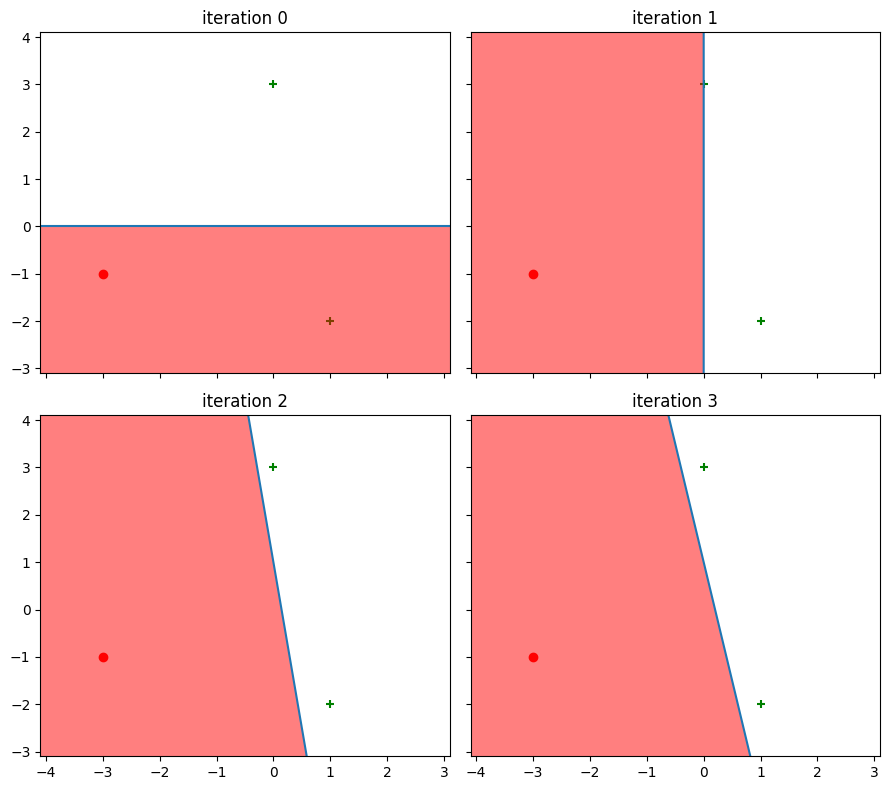

In [10]:
# Initialize weights and bias.
weights = np.array([0.0, 1.0])
bias = 0.0

f, ax_arr = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(9,8))
axs = list(itertools.chain.from_iterable(ax_arr))
for ax in axs:
    ax.set_xlim(-4.1, 3.1); ax.set_ylim(-3.1, 4.1)

run_perceptron(X, Y, weights, bias, axs, 4)

f.tight_layout()

### Problem A-iii

##### Visualize a Non-linearly Separable Dataset.

We will now work on a dataset that cannot be linearly separated, namely one that is generated by the XOR function.

In [11]:
X = np.array([[0, 1], [1, 0], [0, 0], [1, 1]])
Y = np.array([1, 1, -1, -1])

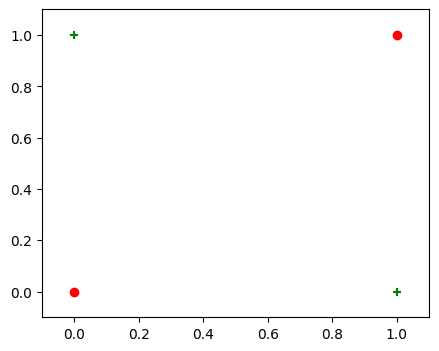

In [12]:
fig = plt.figure(figsize=(5,4))
ax = fig.gca(); ax.set_xlim(-0.1, 1.1); ax.set_ylim(-0.1, 1.1)
plot_data(X, Y, ax)

We will now run the perceptron algorithm on this dataset. We will limit the total timesteps this time, but you should see a pattern in the updates. Run the below code.

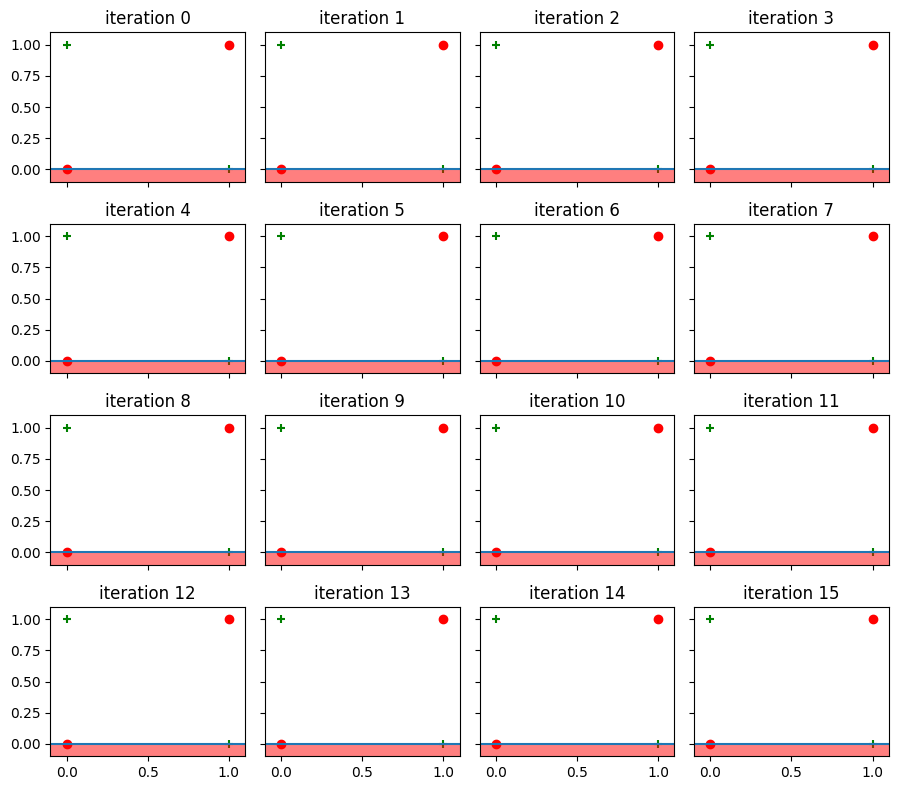

In [13]:
# Initialize weights and bias.
weights = np.array([0.0, 1.0])
bias = 0.0

f, ax_arr = plt.subplots(4, 4, sharex=True, sharey=True, figsize=(9,8))
axs = list(itertools.chain.from_iterable(ax_arr))
for ax in axs:
    ax.set_xlim(-0.1, 1.1); ax.set_ylim(-0.1, 1.1)

run_perceptron(X, Y, weights, bias, axs, 16)

f.tight_layout()

### Problem B

Implement MNIST Classification with MLP. Your `train_mnist` function should return the trained model.

Hint: use the `torchvision` library to load the [MNIST dataset](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html).

In [ ]:
import torch.nn as nn
from torchvision import datasets, transforms

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        #======================================
        # TODO: Define model instance variables
        #======================================

    def forward(self, x):
        #===========================
        # TODO: Forward pass for MLP
        #===========================
        return x

def train_mnist(device = 'cpu'):
    """
    This method performs end to end training of a model for the MNIST
    classification task. Returns the final trained model, which should have
    one intermediate layer with 500 hidden units. Feel free to write helper
    functions/classes.
    """
    model = MLP().to(device)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    #==============================================================
    # TODO: Implement the MLP model, dataloading, and training loop
    # for MNIST classification.
    #==============================================================

    return model